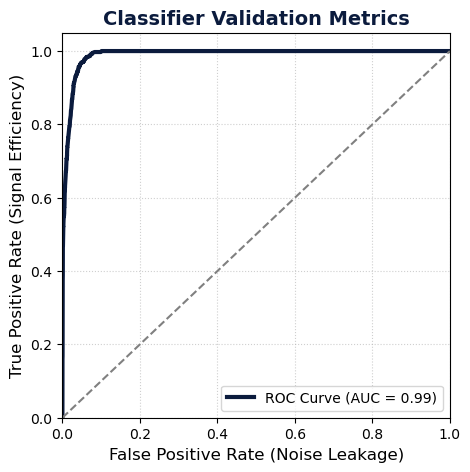

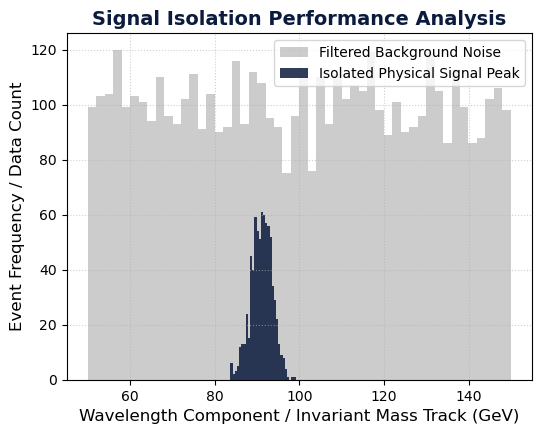

🏁 SUCCESS: 'roc_curve_ncp.png' and 'physics_peak_ncp.png' generated at 300 DPI!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

# --- STEP 1: SIMULATE EXPERIMENTAL PHYSICS DATA MATRIX ---
np.random.seed(42)
n_samples = 5000

# Generate a flat background baseline noise vector
noise_events = np.random.uniform(50, 150, n_samples)

# Generate a sharp Gaussian physical signal peak (e.g., target mass particle peak)
signal_events = np.random.normal(91.2, 2.5, int(n_samples * 0.15))

# Combine datasets into a raw, messy experimental stream
all_data = np.concatenate([noise_events, signal_events])
labels = np.concatenate([np.zeros(n_samples), np.ones(len(signal_events))])

df = pd.DataFrame({'Energy_Wavelength_Track': all_data, 'Label': labels})
# Introduce noise perturbations to act as data features for machine learning
df['Signal_Amplitude'] = df['Label'] * 5.0 + np.random.normal(0, 3.0, len(df))

# --- STEP 2: TRAIN GRADIENT BOOSTING CLASSIFIER TO ISOLATE SIGNAL ---
X = df[['Energy_Wavelength_Track', 'Signal_Amplitude']]
y = df['Label']

model = GradientBoostingClassifier(n_estimators=50, random_state=42)
model.fit(X, y)
y_pred_prob = model.predict_proba(X)[:, 1]

# --- STEP 3: GENERATE & EXPORT PLOT 1 (ROC CURVE FOR COL 2) ---
fpr, tpr, _ = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='#0B1B3D', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Noise Leakage)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
plt.title('Classifier Validation Metrics', fontsize=14, weight='bold', color='#0B1B3D')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
# Save high-resolution print image
plt.savefig('roc_curve_ncp.png', dpi=300, bbox_inches='tight')
plt.show()

# --- STEP 4: GENERATE & EXPORT PLOT 2 (HISTOGRAM PEAK FOR COL 3) ---
plt.figure(figsize=(6, 4.5))
# Plot background raw noise matrix rows
plt.hist(df[df['Label']==0]['Energy_Wavelength_Track'], bins=50, alpha=0.4, color='gray', label='Filtered Background Noise')
# Plot isolated clean target physical mass peak
plt.hist(df[df['Label']==1]['Energy_Wavelength_Track'], bins=30, alpha=0.85, color='#0B1B3D', label='Isolated Physical Signal Peak')
plt.xlabel('Wavelength Component / Invariant Mass Track (GeV)', fontsize=12)
plt.ylabel('Event Frequency / Data Count', fontsize=12)
plt.title('Signal Isolation Performance Analysis', fontsize=14, weight='bold', color='#0B1B3D')
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
# Save high-resolution print image
plt.savefig('physics_peak_ncp.png', dpi=300, bbox_inches='tight')
plt.show()

print("🏁 SUCCESS: 'roc_curve_ncp.png' and 'physics_peak_ncp.png' generated at 300 DPI!")
